<a href="https://colab.research.google.com/github/anumolusuma6/anumolusuma6/blob/main/cmpt726_sp24_a2_OLS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Based on Jupyter Notebook created by Josh Tobin for CS 189 at UC Berkeley

%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from timeit import default_timer as timer

# Part 1: Create a synthetic dataset


## Let's generate some data from a polynomial

$$y_i = -0.2 x_i^4 - 0.6 x_i^3 - 0.5 x_i^2 + 0.3 x_i + 1 + \epsilon_i\mbox{, where }\epsilon_i \sim \mathcal{N}(0,0.1), x_i \sim \mathrm{Uniform}(-1,1)$$



In [2]:
def polynomial(values, coeffs):
    assert len(values.shape) == 2
    # Coeffs are assumed to be in order 0, 1, ..., n-1
    expanded = coeffs[np.newaxis,:] * (values ** np.arange(len(coeffs))[np.newaxis,:])
    return np.sum(expanded, axis=-1)

In [3]:
def polynomial_data(coeffs, n_data=100, x_range=[-1, 1], eps=0.1):
    x = np.random.uniform(x_range[0], x_range[1], n_data)[:,np.newaxis]
    poly = polynomial(x, coeffs)
    noisy_poly = poly + eps * np.random.standard_normal(size=poly.shape)
    return x, noisy_poly

In [4]:
# Generate 50 data points with a fixed random seed
np.random.seed(100)
# 1 + 0.3 * x - 0.5 x^2 - 0.6 x^3 - 0.2 x^4
coeffs = np.array([1., 0.3, -0.5, -0.6, -0.2])
x, y = polynomial_data(coeffs, 50)

## Let's inspect it

In [5]:
# Good to look at shapes, some values
print(x.shape)
print(y.shape)
print(x[:5])
print(y[:5])

(50, 1)
(50,)
[[ 0.08680988]
 [-0.44326123]
 [-0.15096482]
 [ 0.68955226]
 [-0.99056229]]
[1.14083334 0.64425409 0.80963591 0.60394243 0.54839647]


In [28]:
def plot_polynomial(coeffs, x_range=[-1, 1], color='red', label='polynomial', alpha=1.0):
    values = np.linspace(x_range[0], x_range[1], 1000).reshape([-1, 1])
    poly = polynomial(values, coeffs)
    plt.plot(values, poly, color=color, linewidth=2, label=label, alpha=alpha)

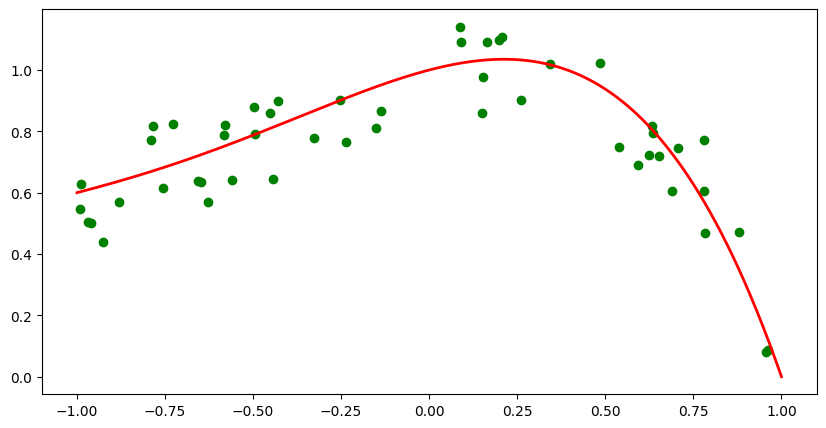

In [29]:
# Visualize the data points and the polynomial curve
plt.figure(figsize=(10, 5))
plt.scatter(x, y, color='green')
plot_polynomial(coeffs)

# Part 2: Ordinary least squares (OLS)

## Let's code up a naive implementation of the OLS solution

$$L(\vec{w}) = \sum_{i=1}^{N} (y_i - \vec{w}^\top\vec{x}_i)^2 = \Vert \vec{y} - X\vec{w} \Vert_2^2$$

$$\tilde{L}(\vec{w}) := {1 \over N}L(\vec{w}) = {1 \over N}\sum_{i=1}^{N} (y_i - \vec{w}^\top\vec{x}_i)^2 \mbox{ ("Mean Squared Error")}$$

$$\vec{w}^{*} := \arg \min_{\vec{w}} \tilde{L}(\vec{w}) = \arg \min_{\vec{w}} L(\vec{w}) =  \left( X^\top X \right)^{-1} X^\top \vec{y} = X^\dagger \vec{y}, \mbox{where } X = \left(\begin{matrix}
\vec{x}_1^\top \\
\vdots \\
\vec{x}_N^\top \\
\end{matrix}\right) \mbox{ and } \vec{y}= \left(\begin{matrix}
y_{1} \\
\vdots \\
y_{N} \\
\end{matrix}\right) $$

If the relation of the data $x$ and the output label $y$ is $\widehat{y} := wx + b$, could we still use the OLS for the linear regression?

Yes, because this is equivalent to:

$$\widehat{y} = \vec{w}^\top\vec{x}\mbox{ where }\vec{w} = \left(\begin{matrix}
w \\
b \\
\end{matrix}\right)\mbox{ and }\vec{x} = \left(\begin{matrix}
x \\
1 \\
\end{matrix}\right)$$

More generally, for data $\vec{x}$, we could use $\vec{y} = \vec{w}^T \phi(\vec{x}) $ where $\phi(\vec{x})$ is the feature that is linear to the output.

In [24]:
def least_squares(feature, y):
    """
    Calculate the coefficients (weights) for ordinary least squares regression.

    Parameters:
    feature (array-like): The feature vectors which is linear to the output label.
    y (vector-like): The labels.

    Returns:
    w: The coefficients (weights) of the linear regression model.
    """
    #<<TODO#1>> Add your code here
    pinv = np.linalg.pinv(feature)
    w = pinv.dot(y)
    return w


def avg_loss(feature, y, w):
  y_hat = feature.dot(w)
  loss = np.mean((y - y_hat) ** 2)
  return loss

In [25]:
# Test the OLS codes
augmented_x = np.hstack([np.ones_like(x), x])

linear_coeff = least_squares(augmented_x, y)

loss = avg_loss(augmented_x, y, linear_coeff)
print(loss)

0.04957829205784526


## Visualize the linear function using the OLS method
The fitting result is not good since the data points are generated by a polynomial function.

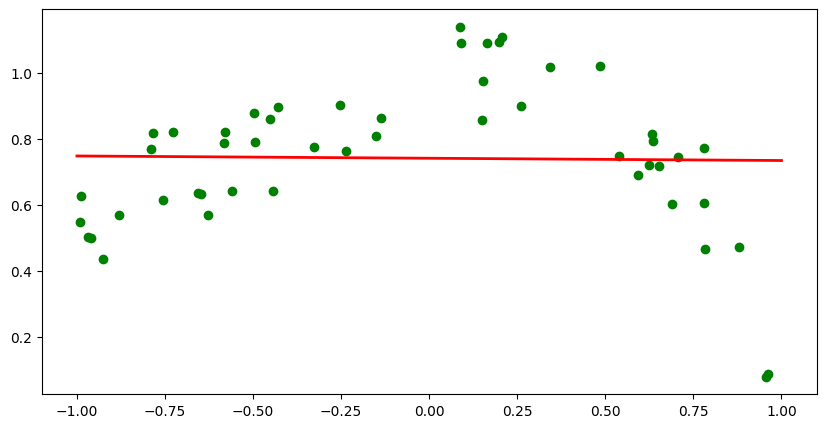

In [30]:
plt.figure(figsize=(10, 5))
plt.scatter(x, y, color='green')
plot_polynomial(linear_coeff)

# Part 3: Polynomial features

$$\vec{x} = \left(\begin{matrix}
1 \\
x \\
x^2 \\
\vdots \\
x^d \\
\end{matrix}\right)$$

$$\hat{y} = \vec{w}^\top\vec{x}\mbox{ where }\vec{w} = \sum_{i=1}^{d}w_i x^i$$

We could treat polynomial features as a vector together so that we could fit a model that is *non-linear* in the input with *linear* regression!

In [31]:
def polynomial_features(x, order):
    features = x ** np.arange(order+1)[np.newaxis,:]
    return features

In [32]:
def plot_regression(x, y, degree):
    start = timer()
    features = polynomial_features(x, degree)
    w = least_squares(features, y)
    loss = avg_loss(features, y, w)
    end = timer()

    plt.figure(figsize=(10, 5))
    plt.scatter(x, y, color='green')
    plot_polynomial(w)
    plt.title(f"Polynomial degree: {degree}, loss: {loss}, time: {end-start}")

## Visualize the linear function using the OLS method again
This time the fitting result is better since we treat the polynomial features together as a linear model.

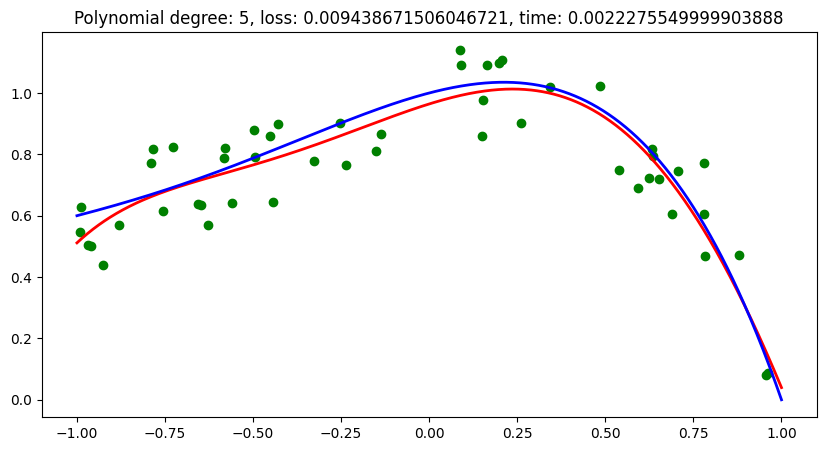

In [33]:
# Visualize the original polynomial curve and the curve with the learned weights
plot_regression(x, y, 5)
plot_polynomial(coeffs, color='blue')

# Part 4:  Hyperparameters
Since we know the degree of the polynomial (usually this is unknown in most scenarios, cross validation is a good way to select a good model), we could use regularization to prevent overfitting. it can be used to improve the generalizability of the model by constraining it at training time. Therefore, we change the loss function to penalize weights with large magnitude.

## L1 Regularization
L1 regularization, also known as Lasso regularization, adds a penalty to the absolute value of the weights in a linear model to the loss function item. This helps to promote sparsity in the model and the weights would contain more zeros or near-zero values.

The cost function for L1 regularization is defined as follows:
\begin{equation}
\begin{aligned}
L(\vec{w}) & =\sum_{i=1}^N\left(y_i-\vec{w}^{\top} \vec{x}_i\right)^2+\lambda\|\vec{w}\|_1 \\
& =\|\vec{y}-X \vec{w}\|_2^2+\lambda\|\vec{w}\|_1
\end{aligned}
\end{equation}
where the 1-norm means the sum of absolute values.

There's no analytical solution using L1 regularizaiton. People usually use numerical method to calculate the weights. One way is as follows (https://www.cs.ubc.ca/~schmidtm/Documents/2005_Notes_Lasso.pdf):
\begin{equation}
\begin{aligned}
& \frac{\partial L}{\partial w}= X^T(X \vec{w} - \vec{y})+\lambda \operatorname{sign}\left(w \right) \\
& w = w - \alpha \frac{\partial L}{\partial w}
\end{aligned}
\end{equation}
where the sign function is the symbolic function, $\alpha$ is the learning rate.

In [38]:
def least_squaresL1_EV(feature, y, Penalty_factor, learning_rate=0.01, n_iterations=10000):
    """
    Calculate the coefficients (weights) for ordinary least squares regression with L1 regularization.

    Parameters:
    feature (array-like): The feature vectors which is linear to the output label.
    y (vector-like): The labels.
    Penalty_factor (scalar):  the penalty factor of the L1 regularization
    learning_rate (scalar): the learing rate of the update during the iteration
    n_iterations (scalar): the number of the iterations

    Returns:
    w: The coefficients (weights) of the linear regression model.
    """
    n_samples, n_features = feature.shape
    # Initialize weights
    w = np.zeros(n_features)

    if Penalty_factor:
      for i in range(n_iterations):
          #<<TODO#2>> Add your code here
            # Calculate the predictions
            predictions = np.dot(feature, w)
            # Calculate the errors
            errors = y - predictions
            # Update weights using L1 regularization
            for j in range(n_features):
                if w[j] > 0:
                    w[j] -= learning_rate * (np.dot(errors, feature[:, j]) - Penalty_factor)
                elif w[j] < 0:
                    w[j] -= learning_rate * (np.dot(errors, feature[:, j]) + Penalty_factor)
                else:
                    w[j] -= learning_rate * np.dot(errors, feature[:, j])
    else:
      w = least_squares(feature, y)

    return w

## L2 Regularization

L2 regularization, also known as Ridge regularization, adds a penalty term to the squared magnitudes of the coefficients in a linear model. This helps to prevent overfitting by discouraging large coefficients and promoting smoothness in the model.

The cost function for L2 regularization is defined as follows:
\begin{equation}
\begin{aligned}
L(\vec{w}) & =\sum_{i=1}^N\left(y_i-\vec{w}^{\top} \vec{x}_i\right)^2+\lambda\|\vec{w}\|_2^2 \\
& =\|\vec{y}-X \vec{w}\|_2^2+\lambda\|\vec{w}\|_2^2
\end{aligned}
\end{equation}

The analytical solution to L2 regularization is:
\begin{equation}
\vec{w}^* = \left(X^{\top} X+\lambda I\right)^{-1} X^{\top} \vec{y}
\end{equation}

In [39]:

def least_squaresL2_EV(feature, y, Penalty_factor):
    """
    Calculate the coefficients (weights) for ordinary least squares regression with L1 regularization.

    Parameters:
    feature (array-like): The feature vectors which is linear to the output label.
    y (vector-like): The labels.
    Penalty_factor (scalar):  the penalty factor of the L2 regularization

    Returns:
    w: The coefficients (weights) of the linear regression model.
    """
    # <<TODO#3>> Add your code here
    # Number of samples and features
    n_samples, n_features = feature.shape

    w = np.linalg.inv(feature.T.dot(feature) + Penalty_factor * np.identity(n_features)).dot(feature.T).dot(y)


    return w

## Comparison between L1 and L2 regularizations



In [40]:
# Generate new data points for testing
np.random.seed(200)
x_new, y_new = polynomial_data(coeffs, 100)

In [41]:
# L2 regularization performance
penalty_factor = 0.5
degree = 4
losses = []
weights = {}

features_train = polynomial_features(x_new, degree)
w = least_squaresL2_EV(features_train, y_new, penalty_factor)
train_loss = avg_loss(features_train, y_new, w)

print(f"When penalty factor ={penalty_factor}: the loss is {train_loss}, the weights are {w}. \n")

When penalty factor =0.5: the loss is 0.0077542470466652426, the weights are [ 0.96938562  0.22657888 -0.31004573 -0.51768677 -0.35364092]. 



In [42]:
# L1 regularization performance
penalty_factor = 0.5
degree = 4
losses = []
weights = {}

features_train = polynomial_features(x_new, degree)
w = least_squaresL1_EV(features_train, y_new, penalty_factor)
train_loss = avg_loss(features_train, y_new, w)

print(f"When penalty factor ={penalty_factor}: the loss is {train_loss}, the weights are {w}. \n")

When penalty factor =0.5: the loss is nan, the weights are [nan nan nan nan nan]. 



## Validation

Usually, we need to decide what degree of polynomial features we should choose (previously we picked 4 because we know how the data was generated, but in practice we don't.)

This is known as "model selection", since different hyperparameter choices result in different models, so we are effectively choosing the model.

In [43]:
def plot_losses(losses, label='loss', color='b'):
    plt.plot(losses, color=color, label=label)
    plt.semilogy()
    plt.legend()
    plt.title(f"Minimum loss achieved at hyperparam value {np.argmin(losses)}")
    plt.xticks(np.arange(len(losses)))

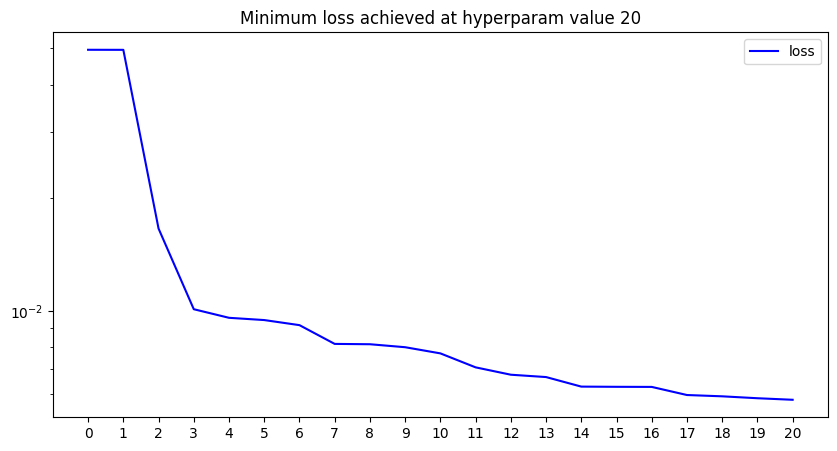

In [44]:
losses = np.empty((21,))
for degree in range(21):
    features = polynomial_features(x, degree)
    w = least_squares(features, y)
    loss = avg_loss(features, y, w)
    losses[degree] = loss

plt.figure(figsize=(10, 5))
plot_losses(losses)

Loss never goes up as we increase the degree!

### Should we choose degree 20?

In [ ]:
plot_regression(x, y, 20)

In [ ]:
plot_regression(x, y, 10)

In [ ]:
plot_regression(x, y, 5)

### Why does this happen?

$$\mbox{Recall }\vec{w}^{*} = X^\dagger \vec{y} \mbox{ and } X^\dagger = V \Sigma^{-1} U^\top $$

$$\mbox{Let's take a look at the singular values of }X \mbox{, i.e.: diagonal entries of }\Sigma$$

In [ ]:
features_20 = polynomial_features(x, 20)
features_20.shape

In [ ]:
_, singular_values_20, _ = np.linalg.svd(features_20)
singular_values_20.min()

In [ ]:
features_5 = polynomial_features(x, 5)
features_5.shape

In [ ]:
_, singular_values_5, _ = np.linalg.svd(features_5)
singular_values_5.min()

$$\mbox{Very small singular value - } X^\top X \mbox{ is close to being non-invertible. As a result, computing }X^\top X \mbox{ and }X^\dagger\mbox{ is numerically unstable.}$$

In [ ]:
w_20 = least_squares(features_20, y)
np.abs(w_20).max()

In [ ]:
w_5 = least_squares(features_5, y)
np.abs(w_5).max()

$$\mbox{Since }\vec{w}^{*} := \left( X^\top X \right)^{-1} X^\top \vec{y} = X^\dagger \vec{y}\mbox{, small singular values of }X\mbox{ causes }\vec{w}^{*}\mbox{ to have elements that are large in magnitude.}$$

$$\mbox{This is bad - large coordinate values of }\vec{w}^{*}\mbox{ make the prediction sensitive to tiny changes in the input. As a result, the model is not robust to noise in the input.}$$

### What happens if we generate new data?

In [ ]:
np.random.seed(300)
x_new, y_new = polynomial_data(coeffs, 50)

In [ ]:
plt.figure(figsize=(10, 5))
plt.scatter(x, y, color='green')
plt.scatter(x_new, y_new, color='blue')

In [ ]:
def plot_regression_new(x, y, x_new, y_new, degree, y_axis_limits = None):
    start = timer()
    features = polynomial_features(x, degree)
    w = least_squares(features, y)
    loss = avg_loss(features, y, w)
    end = timer()

    features_new = polynomial_features(x_new, degree)
    loss_new = avg_loss(features_new, y_new, w)

    plt.figure(figsize=(10, 5))
    plt.scatter(x, y, color='green')
    plt.scatter(x_new, y_new, color='blue')
    plot_polynomial(w)
    if y_axis_limits is not None:
      plt.ylim(y_axis_limits)
    plt.title(f"Polynomial degree: {degree}, loss: {loss}, loss (new): {loss_new}")

In [ ]:
plot_regression_new(x, y, x_new, y_new, 5)

In [ ]:
plot_regression_new(x, y, x_new, y_new, 20, y_axis_limits=(0.0, 1.4))

High-degree polynomial doesn't generalize as well to new data.

Old data which we have access to is known as "training data" or "train data".

New data which we don't have access to is known as "testing data" or "test data".

Loss on the old data is known as "training loss" or "train loss", loss on the new data is known as "testing loss" or "test loss".

Testing loss should approximate the loss we expect the model to incur when it is fed real unseen data.

When both training loss and testing loss are low, the model is said to "generalize" to the testing data.

When testing loss is much higher than the training loss, the model is fitted *too* well to the training data. It fails to generalize to testing data and is said to be "overfitting".

When testing loss is similar to the training loss and is high, the model is not fitted well enough to the training data. In this case, it is said to be "underfitting".

### Another Problem: Instability

In [ ]:
plot_regression(x, y, 4)
plot_regression(x_new, y_new, 4)

In [ ]:
plot_regression(x, y, 20)
plot_regression(x_new, y_new, 20)

This instability is another sign of overfitting.

### What happens if we had more data?

In [ ]:
x_big, y_big = polynomial_data(coeffs, 200)
plot_regression(x_big, y_big, 5)
plot_regression(x_big, y_big, 10)
plot_regression(x_big, y_big, 20)

### Back to picking the optimal hyperparameters

In [ ]:
train_losses = []
test_losses = []
for degree in range(21):
    features = polynomial_features(x, degree)
    w = least_squares(features, y)
    train_loss = avg_loss(features, y, w)
    train_losses.append(train_loss)

    features_new = polynomial_features(x_new, degree)
    test_loss = avg_loss(features_new, y_new, w)
    test_losses.append(test_loss)

plt.figure(figsize=(10, 5))
plot_losses(train_losses, label='training loss', color='b')
plot_losses(test_losses, label='testing loss', color='r')

The difference between the training loss and the testing loss is known as the "generalization gap".

Would like to pick the hyperparameter that results in the lowest testing loss - but can't use testing loss for training or model selection! (Otherwise will overfit to the testing set and make the testing set pointless)

## A Realistic Approach: Validation Sets

Idea: Divide our data into two subsets. Then train model on one subset and pick the hyperparameters based on the other subset.

In [ ]:
N_TRAIN = x.shape[0] // 2
x_train, y_train = x[:N_TRAIN], y[:N_TRAIN]
x_val, y_val = x[N_TRAIN:], y[N_TRAIN:]

train_losses = []
val_losses = []
test_losses = []
for degree in range(21):
    features_train = polynomial_features(x_train, degree)
    w = least_squares(features_train, y_train)
    train_loss = avg_loss(features_train, y_train, w)
    train_losses.append(train_loss)

    features_val = polynomial_features(x_val, degree)
    val_loss = avg_loss(features_val, y_val, w)
    val_losses.append(val_loss)

    features_new = polynomial_features(x_new, degree)
    test_loss = avg_loss(features_new, y_new, w)
    test_losses.append(test_loss)

plt.figure(figsize=(10, 5))
plot_losses(train_losses, label='training loss', color='b')
plot_losses(test_losses, label='testing loss', color='r')
plot_losses(val_losses, label='validation loss', color='g')

## A Better Realistic Approach: Cross-Validation Sets

if we simply split data into train and test tuning a hyperparameter makes the model *see* the test data and knowledge of test data leaks into the model.

Cross-validation splits data into train and test, and train multiple models by sampling the train set. Finally, just test once on the test set.

K-fold cross-validation is a popular technique in machine learning for evaluating the performance of a model. It's particularly useful when you have a limited amount of data and you want to ensure that your model is robust and generalizes well to unseen data.

Here's how k-fold cross-validation works:

Splitting the data: The original dataset is divided into k subsets of roughly equal size. These subsets are often called folds.

Iterative training and testing: The model is trained k times, each time using k-1 folds for training and the remaining fold for testing. So, in each iteration, a different fold is used as the testing set, while the rest are used for training.

Performance evaluation: After training and testing the model k times, the performance metrics (such as accuracy, precision, recall, etc.) are computed for each iteration. Typically, these metrics are averaged over all iterations to get a final evaluation score.

Final model selection: Once cross-validation is complete, you can choose the final model based on the averaged performance across all folds.

In [ ]:
# Generate new data points for testing
np.random.seed(1000)
x, y = polynomial_data(coeffs, 200)

In [ ]:
# Use k-fold cross-validation to select the best degree

Penalty_factor = 0.5
Num_folds = 5  # set k-fold cross-validation k=5
fold_size = x.shape[0]//Num_folds
max_degree = 15

train_losses_mean = []
train_losses_std = []

val_losses_mean = []
val_losses_std = []

test_losses_mean = []
test_losses_std = []


for degree in range(max_degree):

    folds_train_losses = []
    folds_val_losses = []
    folds_test_losses = []

    for f in range(0, Num_folds):
      # <<TODO#4>> Add your code here












plt.figure(figsize=(10, 5))
plot_losses(train_losses_mean, label='training loss', color='b')
std_n = np.array(train_losses_mean) - np.array(train_losses_std)
std_p = np.array(train_losses_mean) + np.array(train_losses_std)
plt.fill_between(range(max_degree), std_n, std_p, color='b', alpha=0.3)

plot_losses(test_losses_mean, label='test loss', color='r')
std_n = np.array(test_losses_mean) - np.array(test_losses_std)
std_p = np.array(test_losses_mean) + np.array(test_losses_std)
plt.fill_between(range(max_degree), std_n, std_p, color='r', alpha=0.3)

plot_losses(val_losses_mean, label='validation loss', color='g')
std_n = np.array(val_losses_mean) - np.array(val_losses_std)
std_p = np.array(val_losses_mean) + np.array(val_losses_std)
plt.fill_between(range(max_degree), std_n, std_p, color='g', alpha=0.3)

print(f"The minimum validation loss is at when the degree equals to {np.argmin(val_losses_mean)}.")

In [ ]:
# Use k-fold cross-validation to select the best penalty factor

Penalty_factors = [0.0, 0.01, 0.1, 0.5, 1.0]
Num_folds = 5  # set k-fold cross-validation k=5
fold_size = x.shape[0]//Num_folds
degree = 4

train_losses_mean = []
train_losses_std = []

val_losses_mean = []
val_losses_std = []

test_losses_mean = []
test_losses_std = []

for Penalty_factor in Penalty_factors:

    folds_train_losses = []
    folds_val_losses = []
    folds_test_losses = []

    for f in range(0, Num_folds):
      # <<TODO#5>> Add your code here



      # w = least_squaresL2_EV(features_train, y_train, Penalty_factor)
      # w = least_squaresL1_EV(features_train, y_train, Penalty_factor)








plt.figure(figsize=(10, 5))
plot_losses(train_losses_mean, label='training loss', color='b')
std_n = np.array(train_losses_mean) - np.array(train_losses_std)
std_p = np.array(train_losses_mean) + np.array(train_losses_std)
plt.fill_between(range(len(Penalty_factors)), std_n, std_p, color='b', alpha=0.3)

plot_losses(test_losses_mean, label='test loss', color='r')
std_n = np.array(test_losses_mean) - np.array(test_losses_std)
std_p = np.array(test_losses_mean) + np.array(test_losses_std)
plt.fill_between(range(len(Penalty_factors)), std_n, std_p, color='r', alpha=0.3)

plot_losses(val_losses_mean, label='validation loss', color='g')
std_n = np.array(val_losses_mean) - np.array(val_losses_std)
std_p = np.array(val_losses_mean) + np.array(val_losses_std)
plt.fill_between(range(len(Penalty_factors)), std_n, std_p, color='g', alpha=0.3)

print(f"The minimum validation loss is at when the penalty factor equals to {Penalty_factors[np.argmin(val_losses_mean)]}.")